##  Análise Exploratória dos Microdados do ENEM (MG)


### Objetivo:
Esta etapa apresenta uma análise exploratória dos dados utilizados no projeto, com o objetivo de compreender padrões gerais de distribuição, relações entre variáveis socioeconômicas e desempenho educacional.

Diferentemente do dashboard interativo do projeto — que explora detalhadamente cada variável — o objetivo deste notebook é investigar padrões estruturais relevantes para a modelagem estatística.

A análise se concentra em três níveis:

* Distribuição das características individuais dos candidatos
* Desigualdades socioeconômicas associadas ao desempenho educacional
* Relações estruturais entre variáveis utilizadas no modelo preditivo

### 1) Importação das bibliotecas

In [1]:
import sys
from pathlib import Path

# Permite importar o pacote `src/` a partir do diretório do projeto.
ROOT_PATH = Path().resolve().parents[1]  # notebooks/00_preprocessamento -> projeto
if str(ROOT_PATH) not in sys.path:
    sys.path.append(str(ROOT_PATH))


import matplotlib.colors as mcolors
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
import sklearn

from platform import python_version


from src.config import (
    DADOS_MG_21_23_NUM, 
    DADOS_MG_21_23,
    DADOS_AGG_MG_ML
    
)

#pandas configurando para mostrar todas as linhas e colunas
pd.set_option ('display.max_columns', None)
#pandas configurando para mostrar todas as linhas e colunas
pd.set_option ('display.max_rows', None)
#configurando pandas para não mostrar notação científica
pd.set_option('display.float_format', lambda x: '%.2f' % x)

sns.set_theme(style="whitegrid", palette="viridis", context="notebook")

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["xtick.labelsize"] = 9
plt.rcParams["ytick.labelsize"] = 9
plt.rcParams["legend.fontsize"] = 9



### 2) Carregamento das bases

A análise utiliza três conjuntos de dados derivados do processo de pré-processamento:

* DADOS_MG_21_23 ->
Microdados tratados contendo observações individuais dos candidatos.
* DADOS_MG_21_23_NUM->
Versão numérica das variáveis categóricas relevantes para análise estatística e cálculo de correlações.
* DADOS_AGG_MG_ML ->
Base agregada utilizada posteriormente na modelagem, onde cada linha representa um perfil socioeducacional médio.

Essa separação permite analisar tanto comportamentos individuais quanto padrões estruturais agregados.

In [2]:
df_agg = pd.read_parquet( DADOS_AGG_MG_ML)
df_corr = pd.read_parquet( DADOS_MG_21_23_NUM)
df= pd.read_parquet( DADOS_MG_21_23)


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 996185 entries, 0 to 996184
Data columns (total 29 columns):
 #   Column            Non-Null Count   Dtype   
---  ------            --------------   -----   
 0   faixa_etaria      996185 non-null  category
 1   sexo              996185 non-null  category
 2   estado_civil      996185 non-null  category
 3   cor_raca          996185 non-null  category
 4   escola            996185 non-null  category
 5   uf                996185 non-null  category
 6   nota_cn           686584 non-null  float32 
 7   nota_ch           720293 non-null  float32 
 8   nota_lc           720293 non-null  float32 
 9   nota_mt           686584 non-null  float32 
 10  lingua            996185 non-null  category
 11  nota_redacao      720293 non-null  float32 
 12  escolaridade_pai  996185 non-null  category
 13  escolaridade_mae  996185 non-null  category
 14  ocup_pai          996185 non-null  category
 15  ocup_mae          996185 non-null  category
 16  n_

### 3) Preparação dos dados para a análise exploratória
Como o foco desta análise exploratória é compreender os padrões associados ao modelo estatístico utilizado no projeto, algumas transformações preliminares são realizadas nos dados.

### Remoção de variáveis não utilizadas na modelagem

Algumas colunas presentes nos microdados originais não são utilizadas diretamente no modelo ou nas análises estruturais realizadas neste notebook. Essas variáveis são removidas para simplificar a base analisada e concentrar a exploração nas variáveis mais relevantes.

Entre elas:

- notas individuais das provas (`nota_cn`, `nota_ch`, `nota_lc`, `nota_mt`, `nota_redacao`);
- variáveis auxiliares do questionário socioeconômico não utilizadas diretamente na modelagem;
- variáveis administrativas como `uf`.

Como o modelo utiliza a variável **`nota_media`** como indicador sintético de desempenho, as notas individuais deixam de ser necessárias nesta etapa da análise.

### Construção de variáveis sintéticas familiares

Duas variáveis adicionais são criadas para representar o contexto socioeconômico familiar de forma mais sintética:

- **`escolaridade_pais_media`**  
  média entre a escolaridade do pai e da mãe, representando o capital educacional familiar.

- **`ocup_pais_media`**  
  média entre as categorias de ocupação dos pais, representando o capital ocupacional familiar.

Essas variáveis são úteis para capturar o **nível médio de capital humano e ocupacional da família**, reduzindo dimensionalidade e facilitando análises de correlação e modelagem.

Essas transformações não alteram o conteúdo substantivo da base, mas tornam a análise exploratória mais focada nas variáveis relevantes para a etapa de modelagem.


In [4]:
# Colunas não utilizadas no modelo
colunas_dropadas = [
    'uf',
    'nota_cn',
    'nota_ch',
    'nota_lc',
    'nota_mt',
    'lingua',
    'nota_redacao',
    'gelad',
    'lv_rp',
    'tv',
    'emp_domst'
]

# Remover colunas
df = df.drop(columns=colunas_dropadas)
df_corr = df_corr.drop(columns=colunas_dropadas)

# Criar variáveis sintéticas familiares
df_corr['escolaridade_pais_media'] = (
    df_corr['escolaridade_pai'] + df_corr['escolaridade_mae']
) / 2

df_corr['ocup_pais_media'] = (
    df_corr['ocup_mae'] + df_corr['ocup_pai']
) / 2

### 4) Estatísticas descritivas
A tabela abaixo resume as principais estatísticas das variáveis presentes nos microdados.

Essas estatísticas ajudam a compreender:

* amplitude das variáveis
* presença de possíveis valores extremos
* ordem de grandeza das variáveis utilizadas na modelagem

In [5]:
df.describe()

,n_pessoas_resd,cel,comptdr,indice_consumo,renda_media,nota_media
count,996185.00,996185.00,996185.00,996185.00,996185.00,723122.00
mean,3.61,2.72,0.94,0.29,3.46,559.21
std,1.26,1.04,0.91,0.12,3.53,94.41
min,1.00,0.00,0.00,0.00,0.50,0.00
25%,3.00,2.00,0.00,0.19,2.00,496.00
50%,4.00,3.00,1.00,0.26,2.00,558.14
75%,4.00,4.00,1.00,0.36,4.00,625.16
max,20.00,4.00,4.00,1.00,22.00,851.04


In [6]:
df.describe(exclude='number')

,faixa_etaria,sexo,estado_civil,cor_raca,escola,escolaridade_pai,escolaridade_mae,ocup_pai,ocup_mae,sal_min,regiao,ano
count,996185,996185,996185,996185,996185,996185,996185,996185,996185,996185,996185,996185
unique,6,2,5,5,3,6,6,6,6,7,13,3
top,até 19,feminino,solteiro,negra,não informada,até fund,até fund,manual/tec,básico,1 a 3,Metrop. de Belo Horizonte,2023
freq,608083,624307,894743,513453,690166,447208,359611,269080,430539,688725,346145,358575


### 5) Distribuição das variáveis categóricas

Os gráficos abaixo mostram a composição da amostra segundo as principais variáveis categóricas do estudo. Essa visualização ajuda a compreender o perfil sociodemográfico predominante na base e contextualiza as análises posteriores de desigualdade educacional.

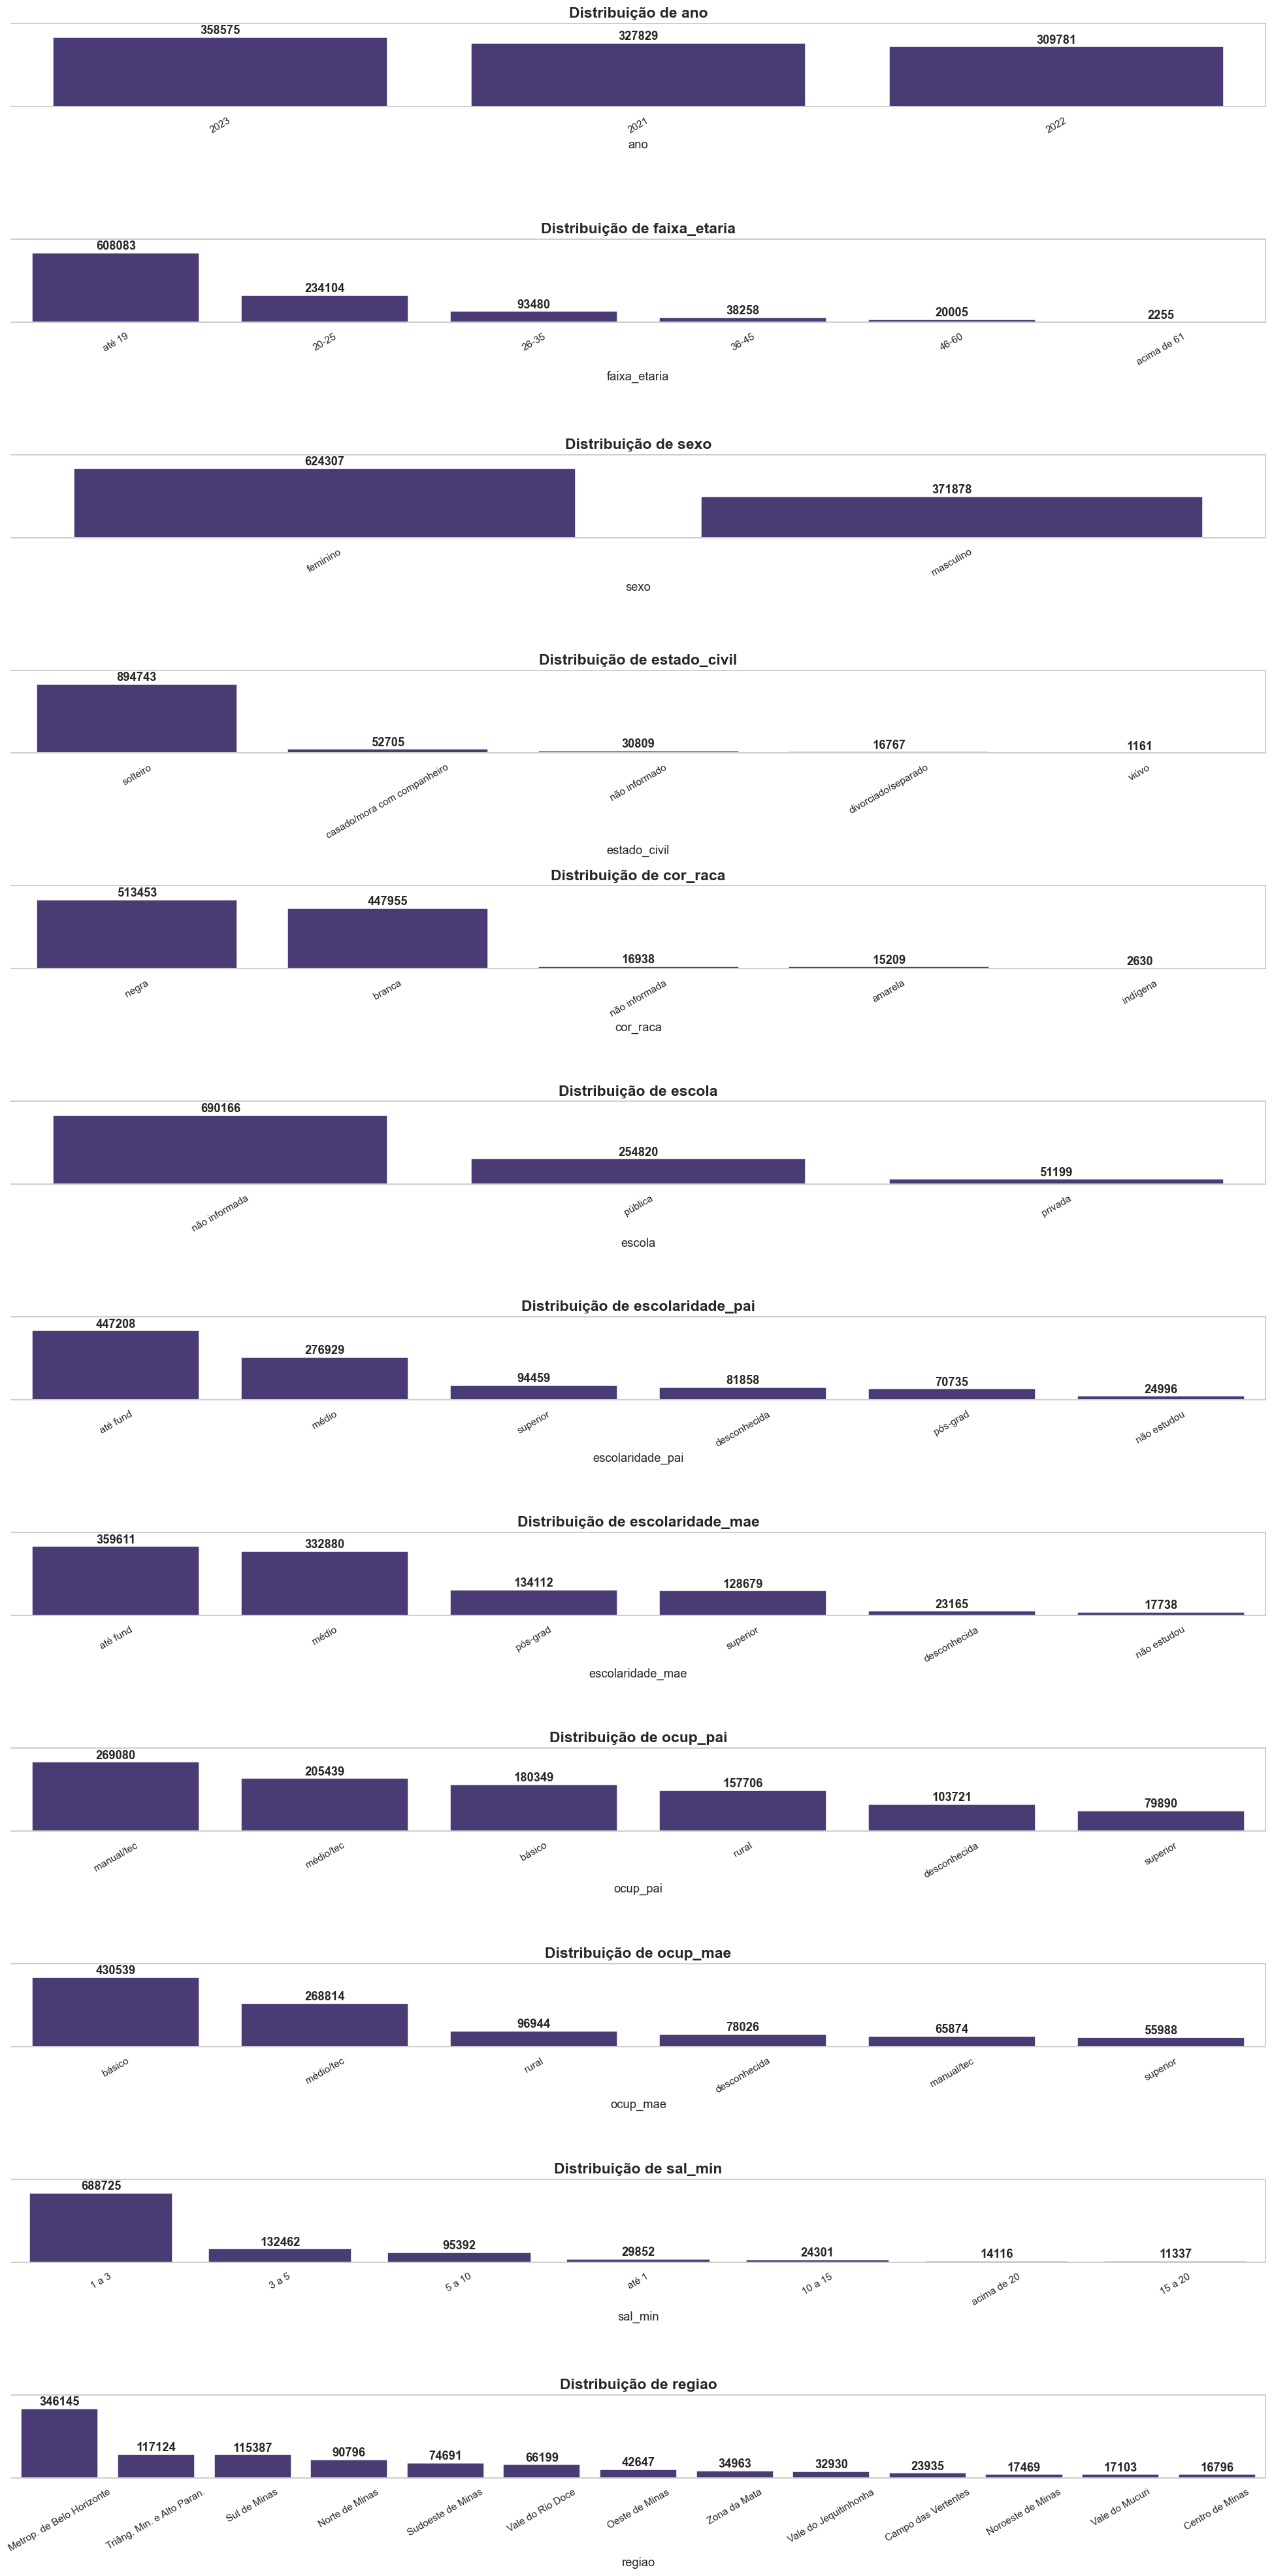

In [7]:
categoricas = list(df.select_dtypes(include="object").columns)
categoricas.extend(list(df.select_dtypes(include="category").columns))

fig, axs = plt.subplots(len(categoricas), 1, figsize=(18, 36))

for ax, coluna in zip(axs, categoricas):
    # Criar o countplot
    sns.countplot(
        data=df,
        x=coluna,
        ax=ax,
        order=df[coluna].value_counts().index
    )
    # Calcular o valor máximo das barras
    max_altura = max([p.get_height() for p in ax.patches])
    
    # Adicionar os valores nas barras
    for p in ax.patches:
        altura = p.get_height()
        
        # Posicionar o texto um pouco acima da barra
        ax.text(p.get_x() + p.get_width()/2., 
                altura + (max(ax.patches, key=lambda x: x.get_height()).get_height() * 0.01), 
                f'{int(altura)}', 
                ha='center', 
                va='bottom',
                fontsize=12,
                fontweight='bold')

    # Aumentar o limite superior do eixo y para dar mais espaço
    ax.set_ylim(0, max_altura * 1.20)  # 15% de espaço extra
    
    # Remover o eixo y
    ax.set_ylabel("")
    ax.set_yticks([])
    ax.set_yticklabels([])
    ax.spines['left'].set_visible(False)
    
    ax.set_title(f"Distribuição de {coluna}", fontsize=15, fontweight='bold')
    ax.set_xlabel(coluna, fontsize=12)
    ax.tick_params(axis="x", rotation=30, labelsize=10)

plt.tight_layout()
plt.show()

### 6) Distribuição das variáveis numéricas

Os histogramas abaixo mostram a distribuição das principais variáveis numéricas utilizadas no projeto.

As distribuições abaixo permitem observar assimetria, dispersão e concentração das variáveis quantitativas mais relevantes para o projeto, incluindo indicadores domiciliares, renda e desempenho médio.

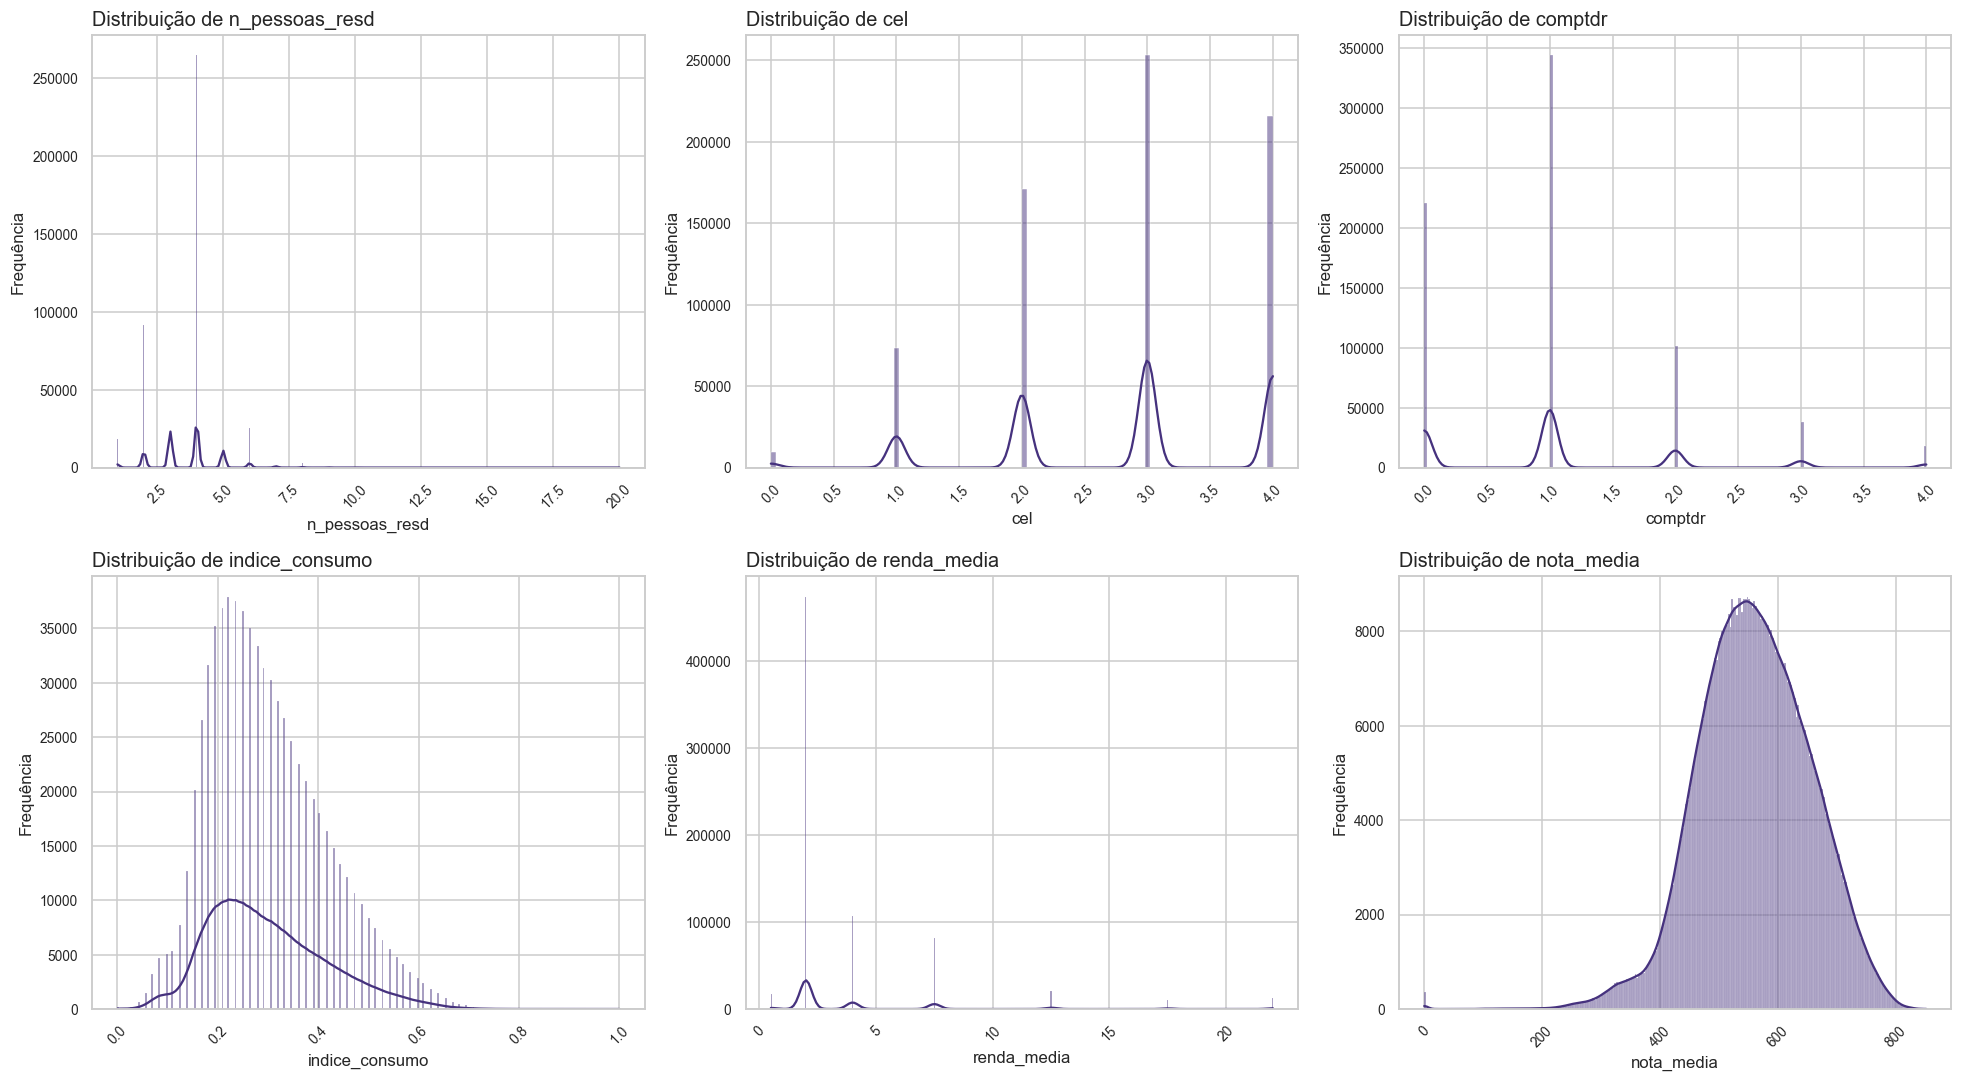

In [8]:
df_modelo = df.dropna(subset=["nota_media"]).copy()

colunas_numericas = df_modelo.select_dtypes("number").columns

fig, axs = plt.subplots(2, 3, figsize=(18, 10))
axs = axs.flatten()

for ax, coluna in zip(axs, colunas_numericas):
    sns.histplot(
        data=df_modelo,
        x=coluna,
        kde=True,
        ax=ax
    )
    ax.set_title(f"Distribuição de {coluna}", loc="left")
    ax.set_xlabel(coluna)
    ax.set_ylabel("Frequência")
    ax.tick_params(axis="x", rotation=45)

# caso sobrem eixos vazios
for ax in axs[len(colunas_numericas):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

### 7) Boxplots 

Comparação das variáveis numéricas por ano, sexo e cor/raça.

Os boxplots abaixo permitem comparar a distribuição das variáveis quantitativas ao longo dos anos analisados, destacando diferenças de posição central, dispersão e possíveis valores extremos.

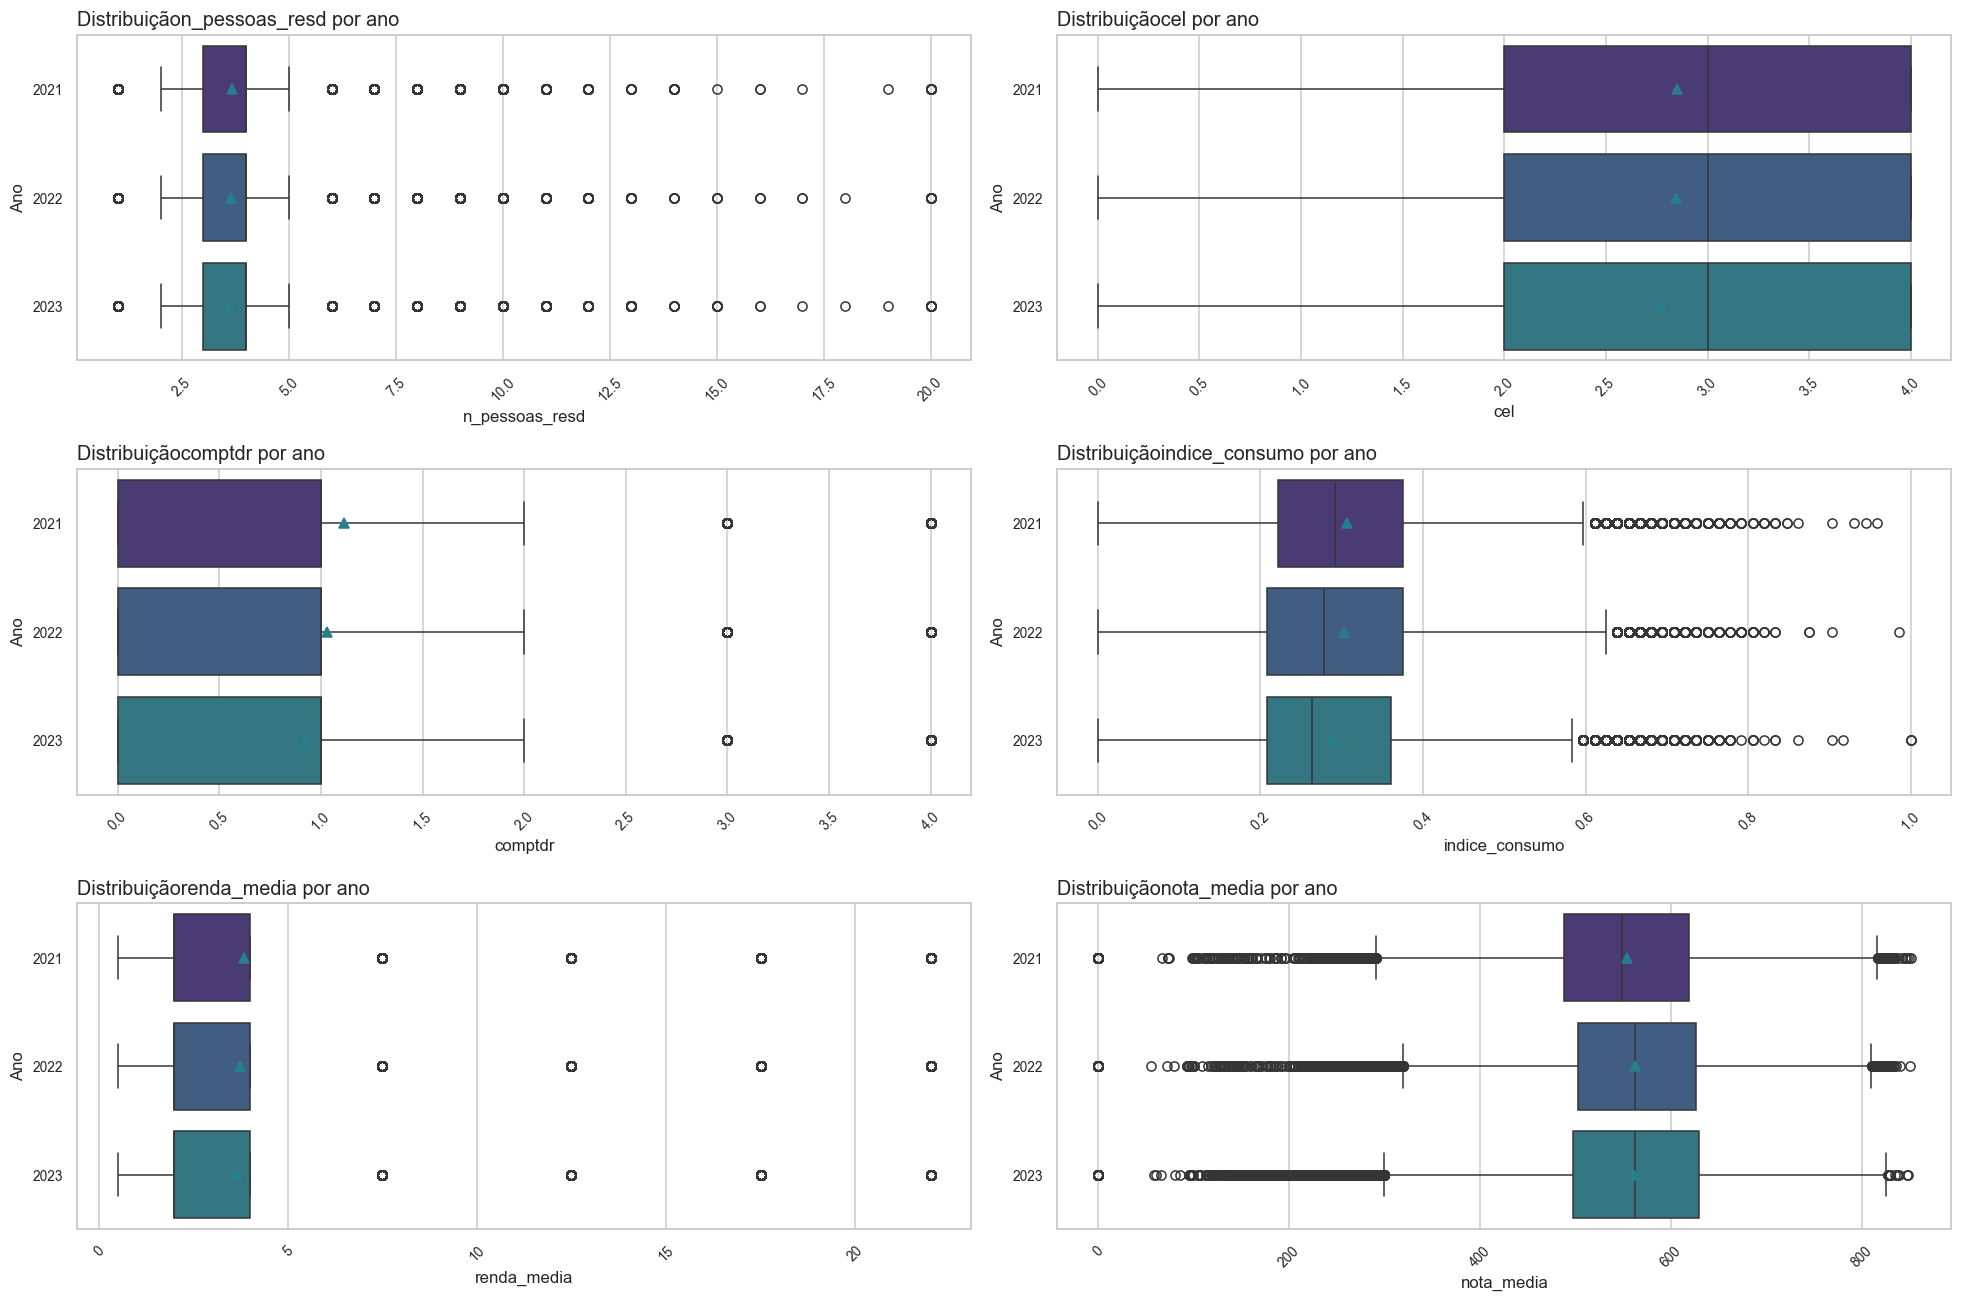

In [11]:
colunas_numericas = df_modelo.select_dtypes("number").columns

fig, axs = plt.subplots(3, 2, figsize=(18, 12))
axs = axs.flatten()

for ax, coluna in zip(axs, colunas_numericas):
    sns.boxplot(
        data=df_modelo,
        x=coluna,
        y="ano",
        hue="ano",
        showmeans=True,
        ax=ax
    )

    legenda = ax.get_legend()
    if legenda is not None:
        legenda.remove()

    ax.set_title(f"Distribuição{coluna} por ano", loc="left")
    ax.set_xlabel(coluna)
    ax.set_ylabel("Ano")
    ax.tick_params(axis="x", rotation=45)

for ax in axs[len(colunas_numericas):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

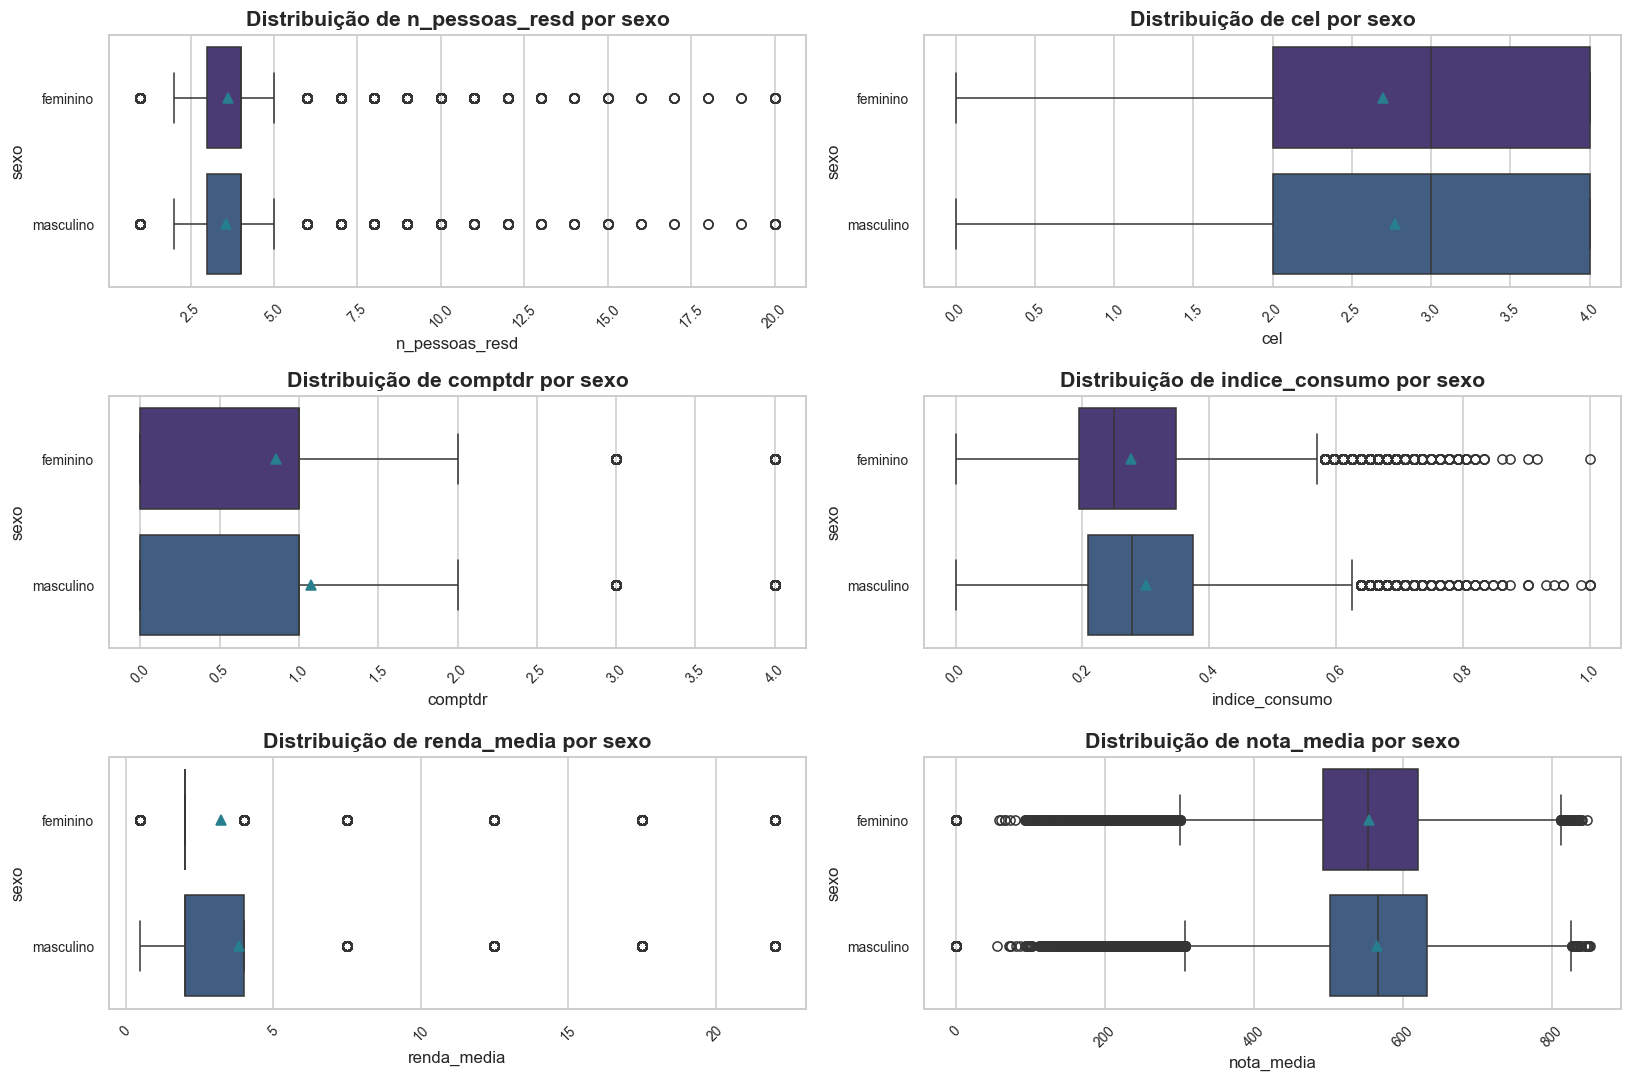

In [12]:
fig, axs = plt.subplots(3, 2 , figsize=(15,10))

for ax, coluna in zip(axs.flatten(),  df.select_dtypes('number').columns):
    sns.boxplot(data = df, ax=ax, x=coluna, showmeans=True, y='sexo', hue='sexo')
    ax.set_title(f"Distribuição de {coluna} por sexo", fontsize=14, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)

    
plt.tight_layout()
plt.show()

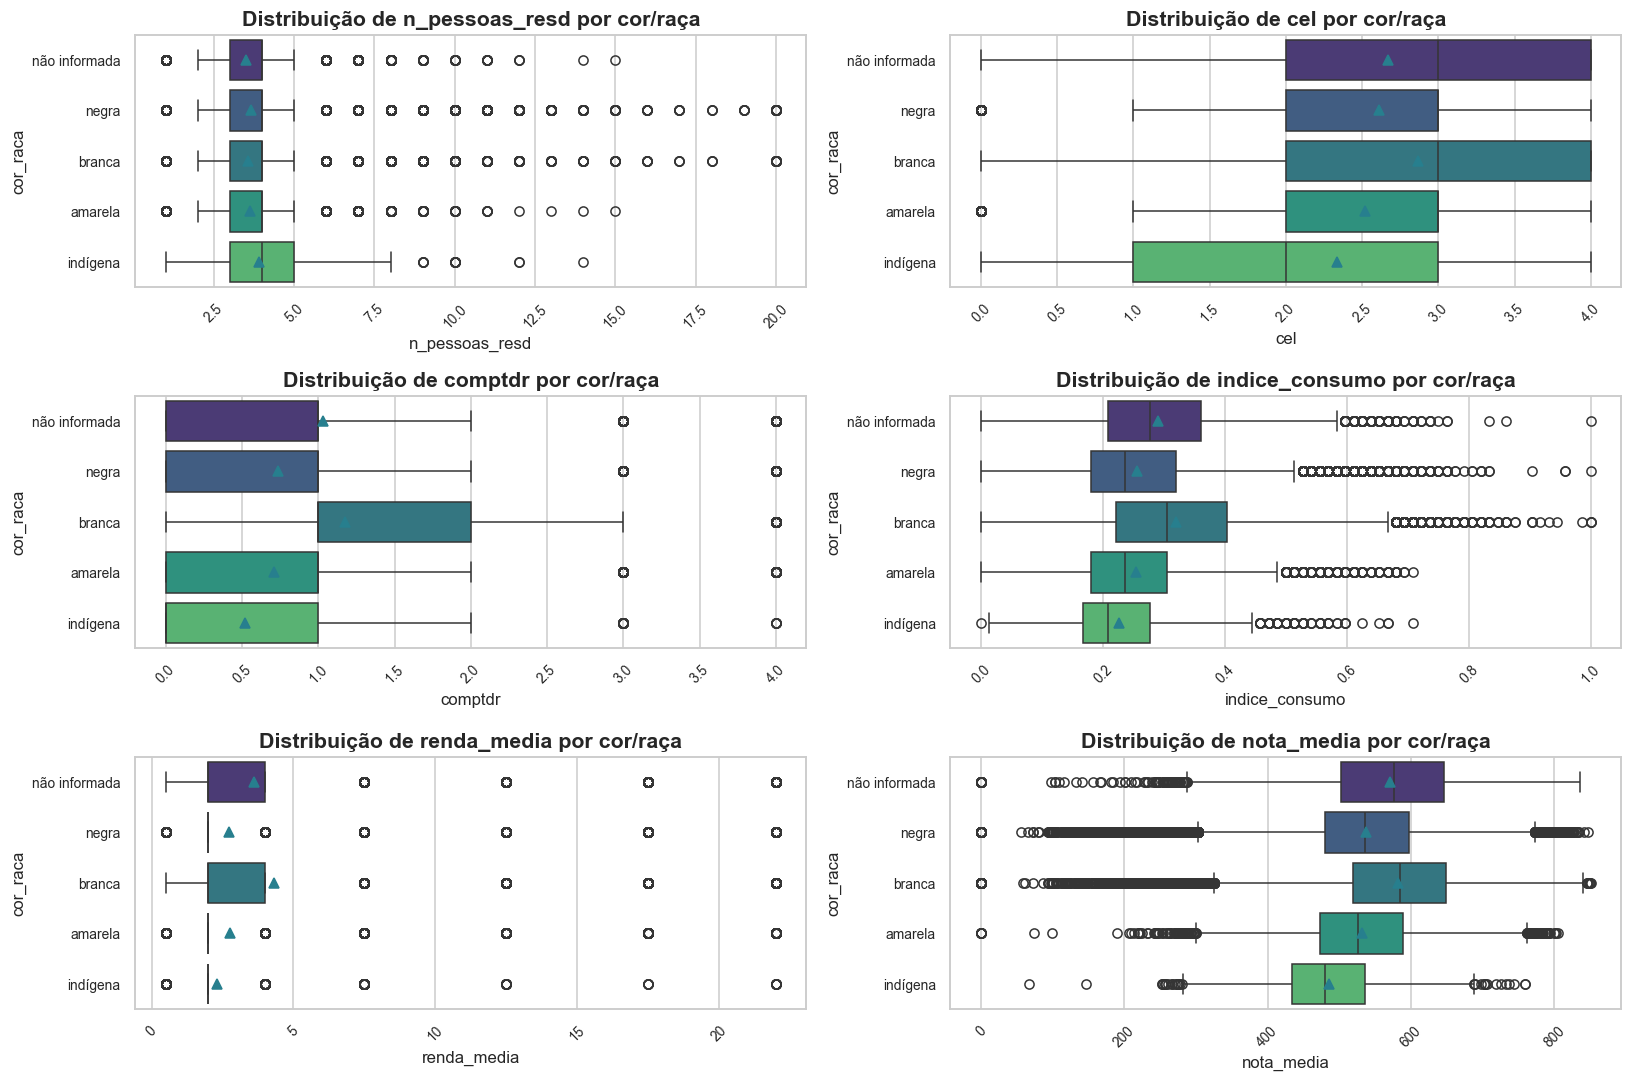

In [13]:
fig, axs = plt.subplots(3, 2 , figsize=(15,10))

for ax, coluna in zip(axs.flatten(),  df.select_dtypes('number').columns):
    sns.boxplot(data = df, ax=ax, x=coluna, showmeans=True, y='cor_raca', hue='cor_raca')
    ax.set_title(f"Distribuição de {coluna} por cor/raça", fontsize=14, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)

    
plt.tight_layout()
plt.show()

### 8) Scatterplot entre renda e desempenho com linha de tendência

O gráfico abaixo explora a associação entre renda média familiar e nota média dos candidatos.

Embora essa visualização não represente uma relação causal, ela fornece uma indicação inicial da correlação positiva frequentemente observada entre condições socioeconômicas e desempenho educacional.

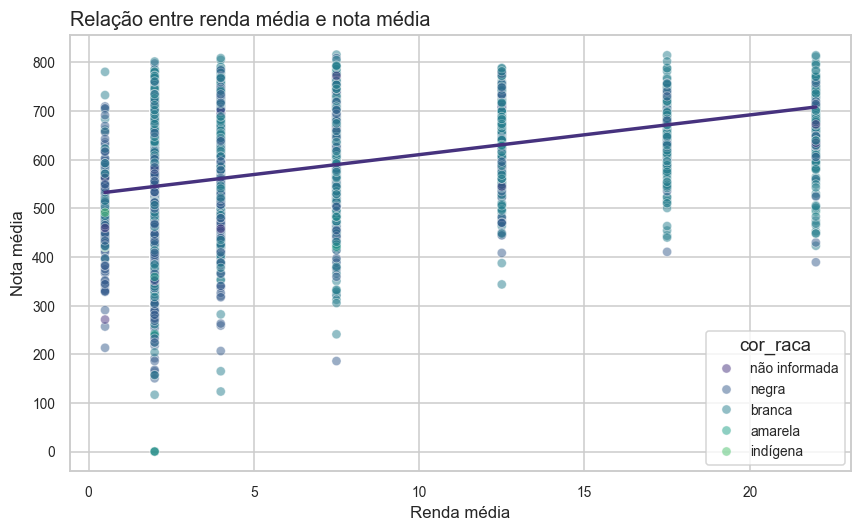

In [14]:
df_plot = df_modelo.sample(min(len(df_modelo), 10000), random_state=42)

fig, ax = plt.subplots(figsize=(8, 5))

sns.scatterplot(
    data=df_plot,
    x="renda_media",
    y="nota_media",
    hue="cor_raca",
    alpha=0.50,
    ax=ax
)

sns.regplot(
    data=df_modelo,
    x="renda_media",
    y="nota_media",
    scatter=False,
    ax=ax
)

ax.set_title("Relação entre renda média e nota média", loc="left")
ax.set_xlabel("Renda média")
ax.set_ylabel("Nota média")

plt.tight_layout()
plt.show()

### 9) Crosstabs

## Comparações entre grupos socioeconômicos

Além da análise gráfica das distribuições, é útil examinar como o desempenho médio varia entre diferentes grupos sociais.

Para isso, utilizei **tabelas de contingência com agregação de média (`pd.crosstab`)**, que permitem observar simultaneamente a relação entre:

- uma variável categórica (por exemplo, raça, tipo de escola ou escolaridade dos pais);
- o ano do exame;
- a média da variável de interesse (`nota_media` ou `renda_media`).

Essas tabelas ajudam a identificar **padrões estruturais de desigualdade educacional**, permitindo comparar como o desempenho médio se distribui entre diferentes grupos ao longo do tempo.

A utilização de **gradientes de cor (`background_gradient`)** facilita a leitura visual dos valores, destacando automaticamente regiões com médias mais altas ou mais baixas.

As tabelas a seguir exploram algumas dimensões relevantes da desigualdade educacional, incluindo:

- raça/cor;
- tipo de escola;
- região do estado;
- escolaridade dos pais;
- ocupação dos pais;
- faixa etária e estado civil.

Essas comparações não devem ser interpretadas como relações causais, mas como **descrições estruturais dos padrões observados nos dados**.

In [15]:
# ------------------------------------------------------------
# Funções auxiliares para visualização exploratória
# ------------------------------------------------------------

def tabela_media(df, linha, coluna, valor, titulo, aggfunc='mean'):
    tabela = (
        pd.crosstab(
            df[linha],
            df[coluna],
            values=df[valor],
            aggfunc=aggfunc
        )
        .style
        .background_gradient(cmap="RdYlGn", axis=1)
        .format("{:.1f}")
        .set_caption(titulo)
    )
    return tabela

#### Desempenho médio por renda e ano

In [16]:
tabela_media(
    df,
    "ano",
    "sal_min",
    "nota_media",
    "Nota média por ano e renda mensal familiar"
)

sal_min,até 1,1 a 3,3 a 5,5 a 10,10 a 15,15 a 20,acima de 20
ano,,,,,,,
2021,492.1,531.6,581.6,608.4,628.5,636.9,641.8
2022,497.1,541.3,591.5,618.8,635.5,644.1,647.4
2023,497.6,539.7,593.3,621.8,640.3,646.2,652.5


### Análise por raça/cor

As tabelas abaixo apresentam as análise da renda mensal e nota média por raça/cor ao longo dos anos analisados.

Esse tipo de comparação permite observar possíveis diferenças sistemáticas de desempenho associadas a desigualdades socioeconômicas e educacionais.

In [17]:
tabela_media(
    df,
    "cor_raca",
    "sal_min",
    "ano",
    "Distribuição da renda média por cor/raça e quantidade de candidatos",
    aggfunc='count',
    
)

sal_min,até 1,1 a 3,3 a 5,5 a 10,10 a 15,15 a 20,acima de 20
cor_raca,,,,,,,
não informada,702.0,10962.0,2443.0,1891.0,514.0,197.0,229.0
negra,20547.0,397115.0,55088.0,30719.0,5824.0,2152.0,2008.0
branca,7744.0,266550.0,73358.0,61853.0,17780.0,8900.0,11770.0
amarela,625.0,11969.0,1419.0,845.0,169.0,83.0,99.0
indígena,234.0,2129.0,154.0,84.0,14.0,5.0,10.0


In [18]:
tabela_media(
    df,
    "ano",
    'cor_raca',
    "renda_media",
    "Renda média por cor/raça",    
)


cor_raca,não informada,negra,branca,amarela,indígena
ano,,,,,
2021,3.6,2.8,4.4,2.7,2.4
2022,3.6,2.8,4.3,2.8,2.4
2023,3.6,2.7,4.2,2.8,2.2


### Desempenho médio por tipo de escola

O tipo de escola frequentada (pública ou privada) é uma das variáveis mais relevantes para explicar diferenças de desempenho no ENEM.

A tabela abaixo mostra a média das notas por tipo de escola ao longo dos anos.

In [19]:
tabela_media(
    df,
    "ano",
    "escola",
    "nota_media",
    "Nota média por ano e tipo de escola"
)


escola,pública,não informada,privada
ano,,,
2021,528.3,556.8,631.4
2022,538.8,565.1,634.0
2023,535.1,562.7,644.3


### Desempenho médio por região

A distribuição regional do desempenho pode revelar diferenças estruturais associadas a:

* condições socioeconômicas locais
* infraestrutura educacional
* desigualdades regionais históricas.

In [20]:
tabela_media(
    df,
    "ano",
    "regiao",
    "nota_media",
    "Nota média por região de Minas Gerais"
)


regiao,Campo das Vertentes,Centro de Minas,Metrop. de Belo Horizonte,Noroeste de Minas,Norte de Minas,Oeste de Minas,Sudoeste de Minas,Sul de Minas,Triâng. Min. e Alto Paran.,Vale do Jequitinhonha,Vale do Mucuri,Vale do Rio Doce,Zona da Mata
ano,,,,,,,,,,,,,
2021,557.2,550.8,564.9,521.0,531.2,558.6,557.2,553.2,552.9,523.1,530.5,556.2,546.7
2022,566.7,558.7,573.8,530.9,541.8,570.3,567.9,561.8,560.8,526.7,533.1,561.8,559.4
2023,563.9,555.1,570.6,531.2,538.3,571.8,565.3,562.7,561.8,524.6,529.8,561.8,562.2


In [21]:
tabela_media(
    df,
    "ano",
    "regiao",
    "renda_media",
    "Renda média por região de Minas Gerais"
)



regiao,Campo das Vertentes,Centro de Minas,Metrop. de Belo Horizonte,Noroeste de Minas,Norte de Minas,Oeste de Minas,Sudoeste de Minas,Sul de Minas,Triâng. Min. e Alto Paran.,Vale do Jequitinhonha,Vale do Mucuri,Vale do Rio Doce,Zona da Mata
ano,,,,,,,,,,,,,
2021,3.1,3.2,4.0,3.1,2.7,3.4,3.4,3.4,3.7,2.5,2.8,3.4,3.0
2022,3.1,3.1,4.0,3.1,2.7,3.3,3.4,3.4,3.8,2.4,2.7,3.3,2.9
2023,3.0,3.0,3.8,3.0,2.6,3.3,3.3,3.3,3.8,2.3,2.6,3.2,2.9


### Desempenho médio por ocupação e escolaridade dos pais

In [22]:
tabela_media(
    df,
    "ano",
    "ocup_pai",
    "nota_media",
    "Nota média por ocupação do pai"
)


ocup_pai,desconhecida,rural,básico,manual/tec,médio/tec,superior
ano,,,,,,
2021,528.7,515.4,533.9,541.5,588.2,616.9
2022,533.0,523.2,544.6,550.9,597.2,624.1
2023,531.2,521.2,541.9,550.9,601.1,627.4


In [23]:
tabela_media(
    df,
    "ano",
    "ocup_mae",
    "nota_media",
    "Nota média por ocupação da mae"
)


ocup_mae,desconhecida,rural,básico,manual/tec,médio/tec,superior
ano,,,,,,
2021,540.2,509.1,535.1,543.1,582.0,618.5
2022,543.6,515.2,544.6,549.8,591.3,625.1
2023,541.7,512.0,542.7,551.0,593.8,626.7


In [24]:
tabela_media(
    df,
    "ano",
    "escolaridade_mae",
    "nota_media",
    "Nota média por escolaridade da mãe"
)

escolaridade_mae,desconhecida,não estudou,até fund,médio,superior,pós-grad
ano,,,,,,
2021,506.2,483.4,523.8,552.5,588.9,596.7
2022,513.6,486.0,531.0,560.4,598.2,605.8
2023,513.8,482.2,528.3,559.3,600.1,608.8


In [25]:
tabela_media(
    df,
    "ano",
    "escolaridade_pai",
    "nota_media",
    "Nota média por escolaridade da pai"
)

escolaridade_pai,desconhecida,não estudou,até fund,médio,superior,pós-grad
ano,,,,,,
2021,524.1,488.3,531.1,561.8,601.8,615.8
2022,529.7,494.9,539.5,570.3,609.9,623.4
2023,529.8,489.8,537.5,569.7,613.2,627.3


### Nota média por estado civil

In [26]:
tabela_media(
    df,
    "ano",
    "estado_civil",
    "nota_media",
    "Nota média por estado civil"
)


estado_civil,não informado,solteiro,casado/mora com companheiro,divorciado/separado,viúvo
ano,,,,,
2021,542.9,555.9,526.8,522.9,493.0
2022,546.4,564.6,532.6,526.1,492.6
2023,544.3,563.5,527.5,523.2,482.3


### Nota média por faixa etária

In [27]:
tabela_media(
    df,
    "ano",
    "faixa_etaria",
    "nota_media",
    "Nota média por faixa etária"
)


faixa_etaria,até 19,20-25,26-35,36-45,46-60,acima de 61
ano,,,,,,
2021,553.7,564.3,551.3,521.7,507.1,489.7
2022,562.4,573.6,556.4,527.1,507.6,492.8
2023,562.3,570.2,551.9,523.2,499.9,475.1


### Nota média por sexo

### 10) Gráfico da base agregada com tamanho dos grupos

Após a agregação por Ano × Faixa de renda × Tipo de escola, cada linha da base agregada representa um perfil socioeducacional médio.

A variável Participantes indica quantos candidatos compõem cada grupo.

Avaliar essa distribuição é importante porque:

* grupos muito pequenos podem gerar médias instáveis;
* grupos maiores produzem estimativas mais robustas;
* a distribuição de Participantes ajuda a justificar a utilização posterior de pesos estatísticos na modelagem.

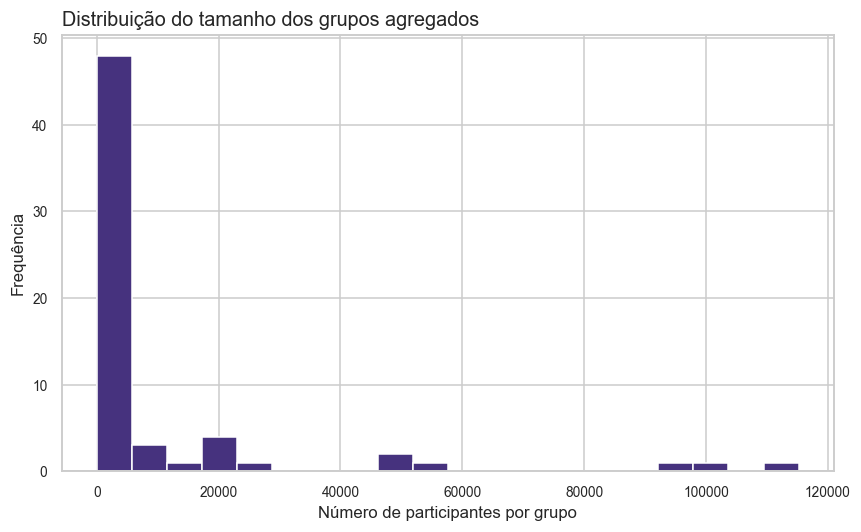

In [28]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(df_agg["Participantes"], bins=20)
ax.set_title("Distribuição do tamanho dos grupos agregados", loc="left")
ax.set_xlabel("Número de participantes por grupo")
ax.set_ylabel("Frequência")

plt.tight_layout()
plt.show()

### 11) Gráfico da base agregada: escolaridade dos pais e nota média
Como a base agregada busca capturar relações estruturais entre condições socioeconômicas e desempenho, é útil visualizar a associação entre:

Renda média
Nota Média
Esse gráfico não substitui a modelagem, mas oferece uma primeira leitura da direção da relação esperada.

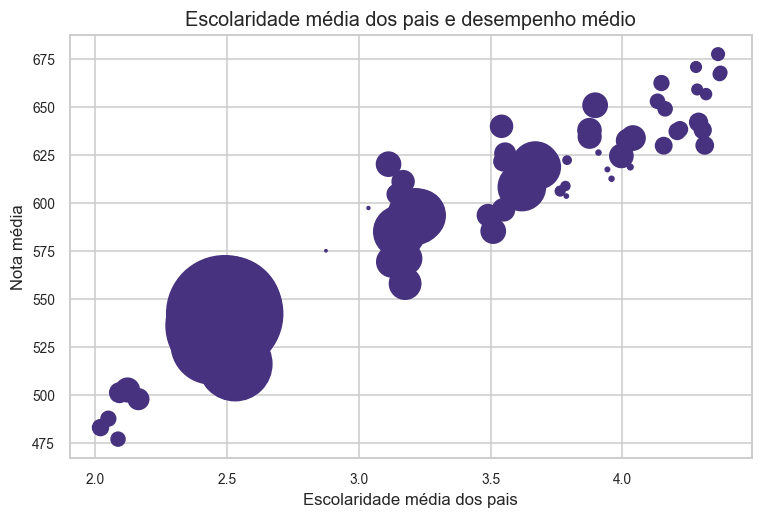

In [29]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df_agg["EscolaridadePaisMedia"], df_agg["NotaMedia"], s=df_agg["Participantes"] / 20)
ax.set_title("Escolaridade média dos pais e desempenho médio")
ax.set_xlabel("Escolaridade média dos pais")
ax.set_ylabel("Nota média")
plt.show()

O tamanho dos pontos representa o número de participantes de cada grupo agregado.

### 12) Grafico da base agregada da nota média por faixa de renda e tipo de escola

Uma das motivações centrais da agregação é permitir comparações estruturais entre perfis socioeconômicos.
A visualização abaixo ajuda a observar como o desempenho médio varia simultaneamente por:

* faixa de renda (SalMin)
* tipo de escola (Escola)

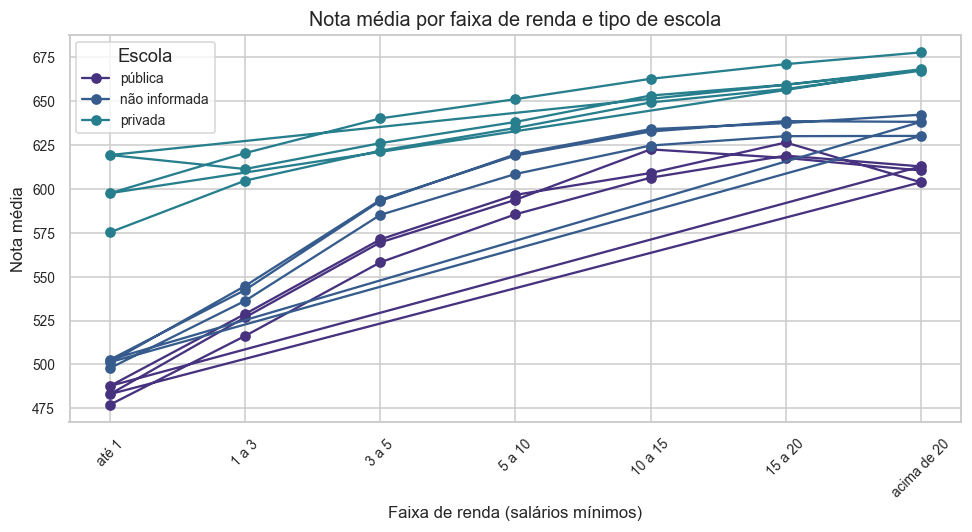

In [30]:
fig, ax = plt.subplots(figsize=(9, 5))

for escola in df_agg["Escola"].astype(str).unique():
    base_plot = df_agg[df_agg["Escola"].astype(str) == escola].copy()
    base_plot = base_plot.sort_values(["Ano", "SalMin"])
    ax.plot(base_plot["SalMin"].astype(str), base_plot["NotaMedia"], marker="o", label=escola)

ax.set_title("Nota média por faixa de renda e tipo de escola")
ax.set_xlabel("Faixa de renda (salários mínimos)")
ax.set_ylabel("Nota média")
ax.legend(title="Escola")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 13) Heatmap Correlação

Correlação entre variáveis socioeconômicas

A matriz de correlação permite observar associações lineares entre as variáveis utilizadas na análise.

O objetivo aqui não é inferir causalidade, mas identificar padrões de associação relevantes para a etapa de modelagem.

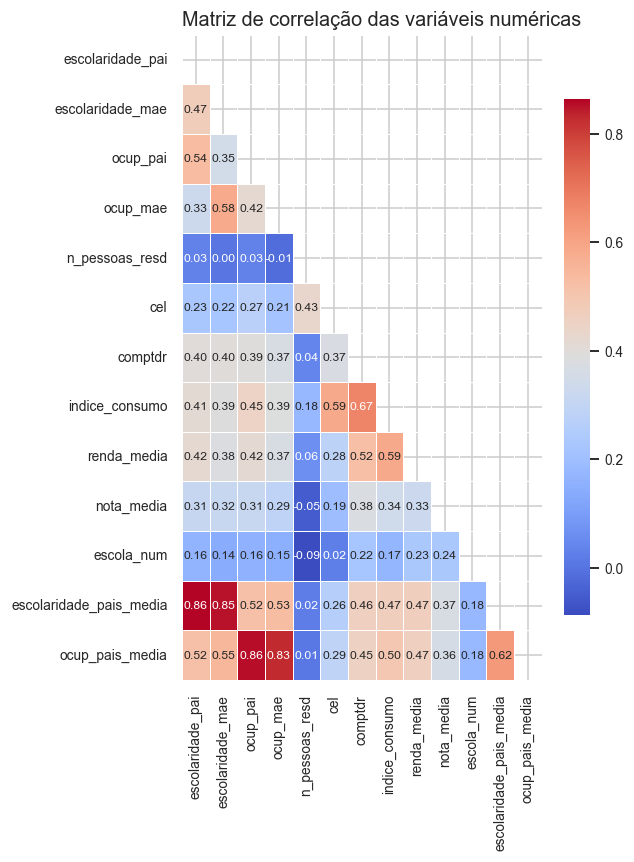

In [31]:
corr = df_corr.select_dtypes("number").corr()
matriz = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(6, 8))

sns.heatmap(
    corr,
    mask=matriz,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    annot_kws={"fontsize": 8},
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    ax=ax
)

ax.set_title("Matriz de correlação das variáveis numéricas", loc="left")
plt.tight_layout()
plt.show()

### 14) Pairplot 

O gráfico abaixo apresenta relações bivariadas entre variáveis socioeconômicas e indicadores de infraestrutura domiciliar.

Para melhorar a visualização e reduzir custo computacional, foi utilizada uma amostra aleatória da base.

In [32]:
colunas_pairplot=['cel', 'escolaridade_pais_media', 'ocup_pais_media', 'comptdr', 'nota_media', 'indice_consumo','renda_media']

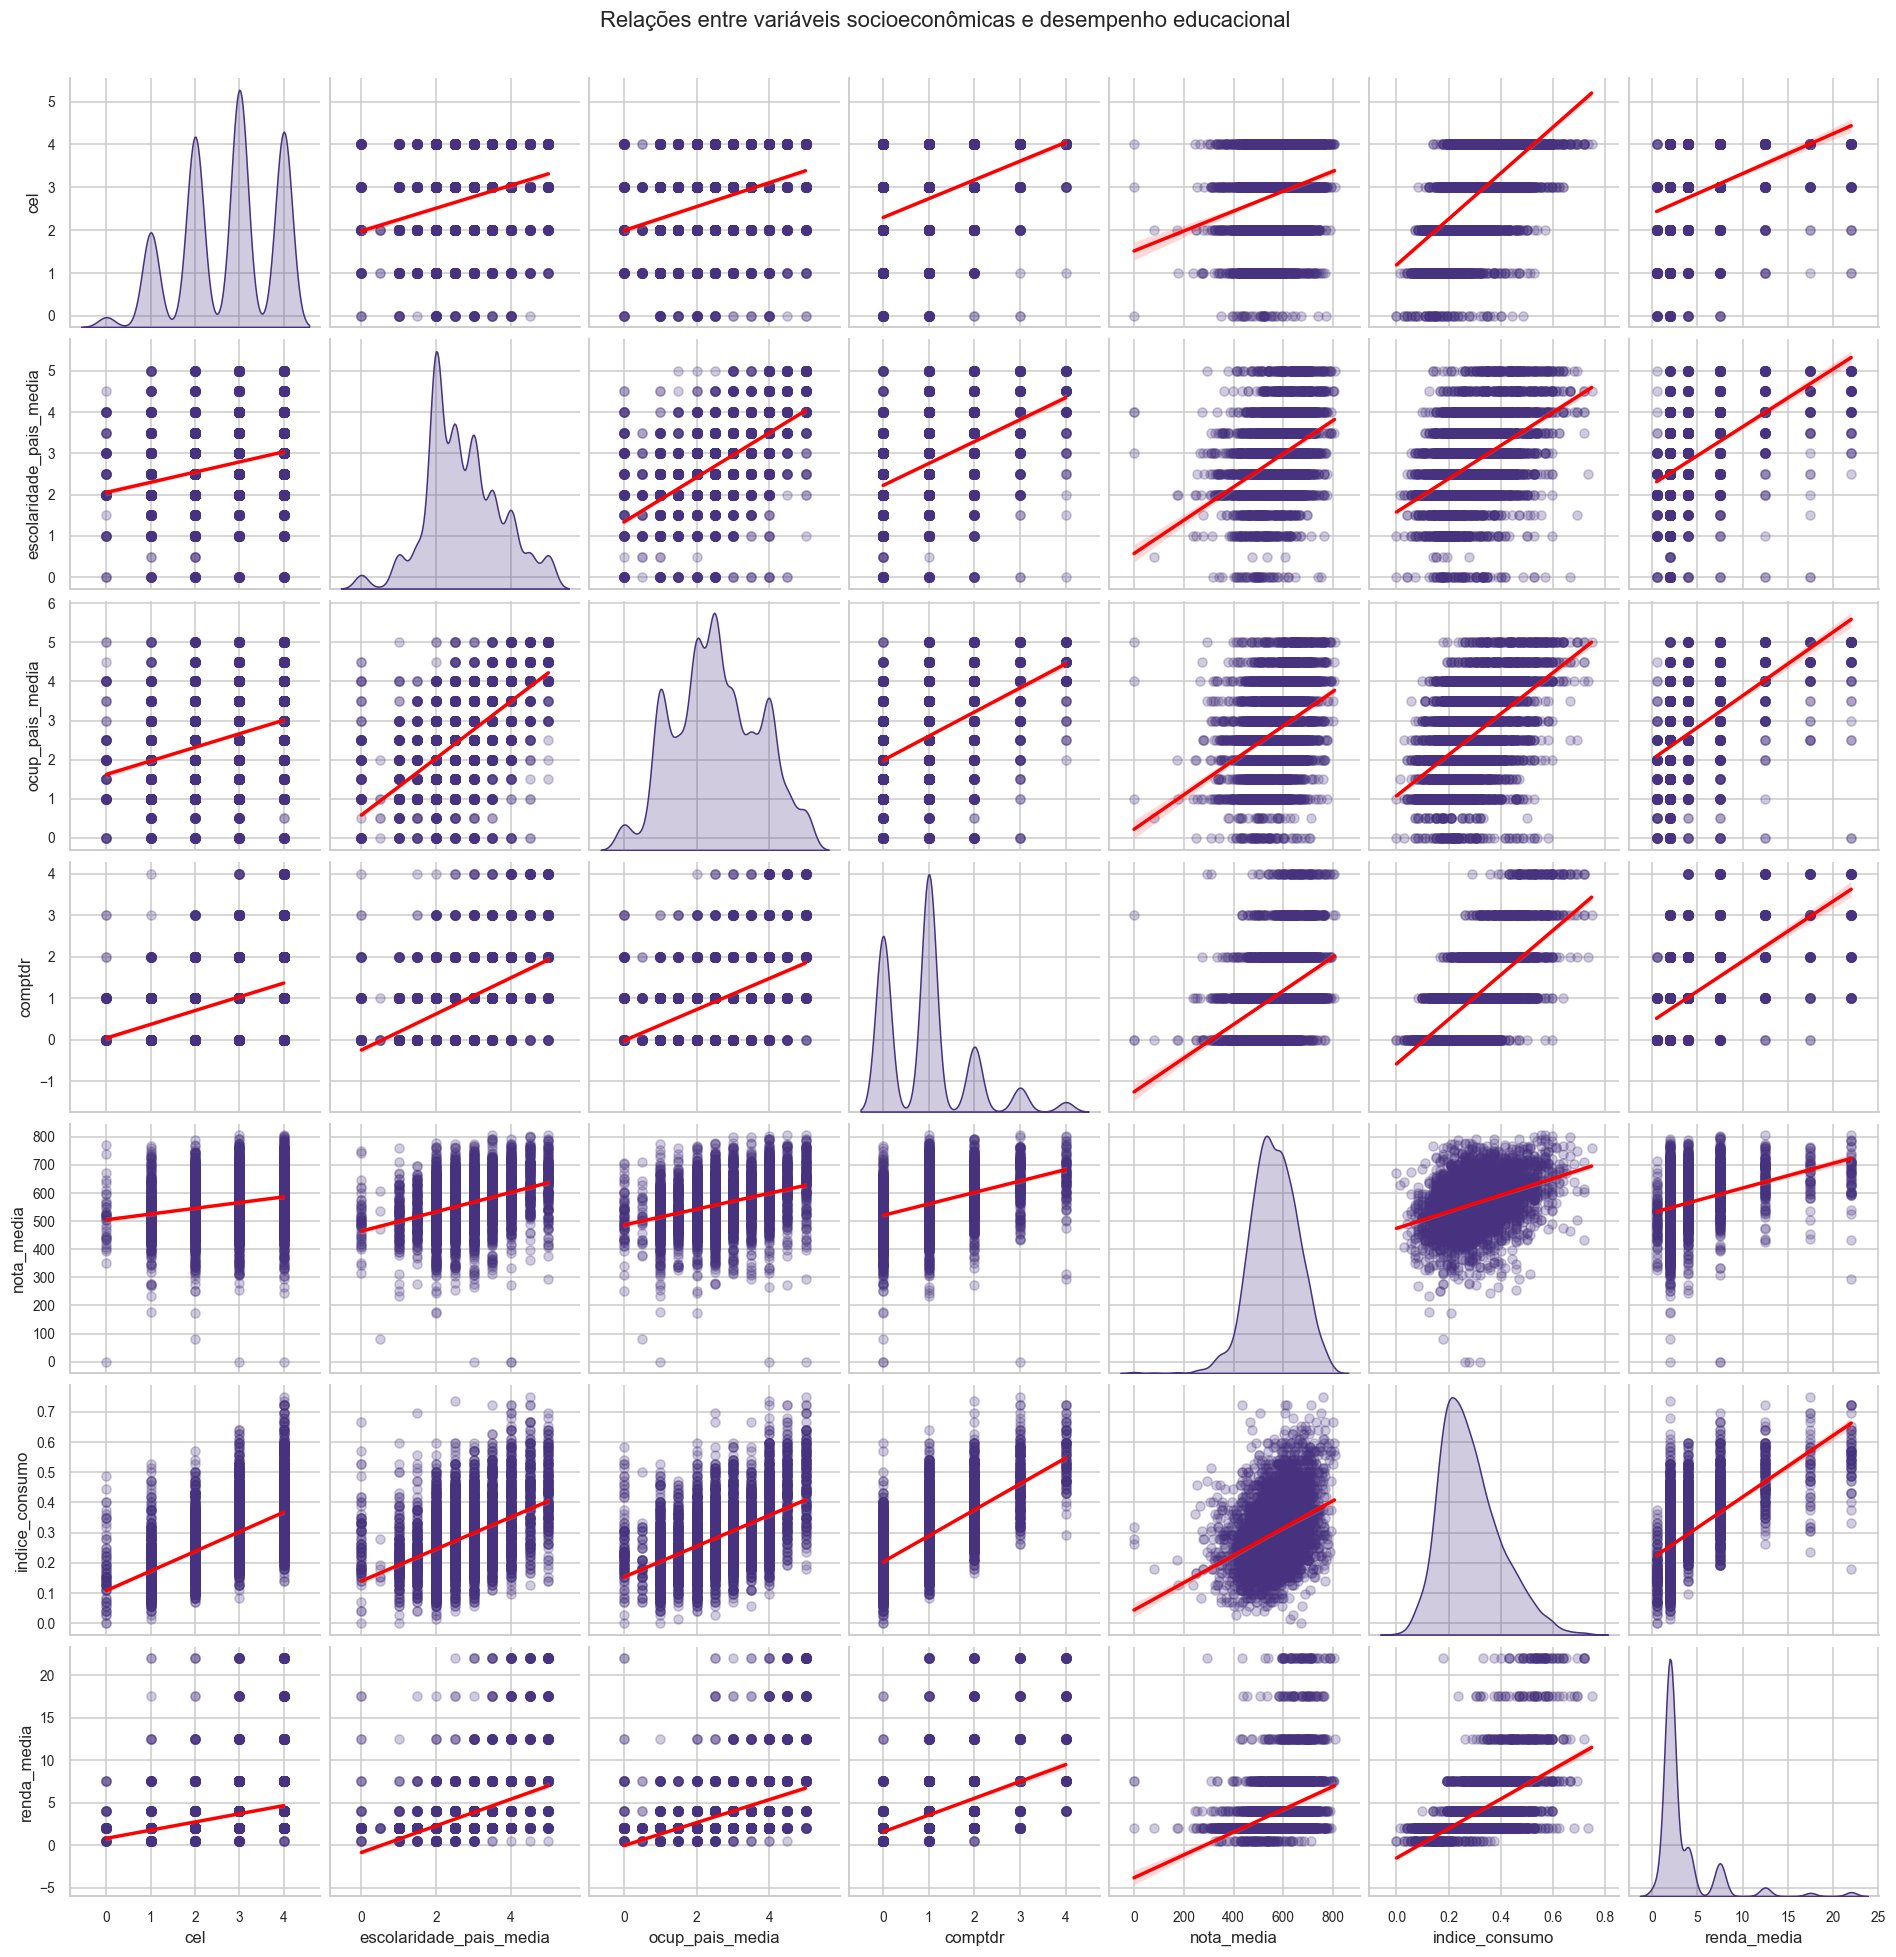

In [33]:
df_sample = df_corr.sample(5000, random_state=42)

colunas_pairplot = [
    "cel",
    "escolaridade_pais_media",
    "ocup_pais_media",
    "comptdr",
    "nota_media",
    "indice_consumo",
    "renda_media"
]

g = sns.pairplot(
    df_sample,
    vars=colunas_pairplot,
    kind="reg",
    diag_kind="kde",
    plot_kws={
        "line_kws": {"color": "red"},
        "scatter_kws": {"alpha": 0.25}
    }
)

g.fig.suptitle(
    "Relações entre variáveis socioeconômicas e desempenho educacional",
    y=1.02
)

plt.show()

### Relação coma nota média 

#### Relação entre variáveis socioeconômicas e desempenho

O pairplot abaixo foca na relação entre diferentes variáveis socioeconômicas e a variável alvo do modelo (`nota_media`).

A cor dos pontos representa o tipo de escola frequentada pelo candidato.

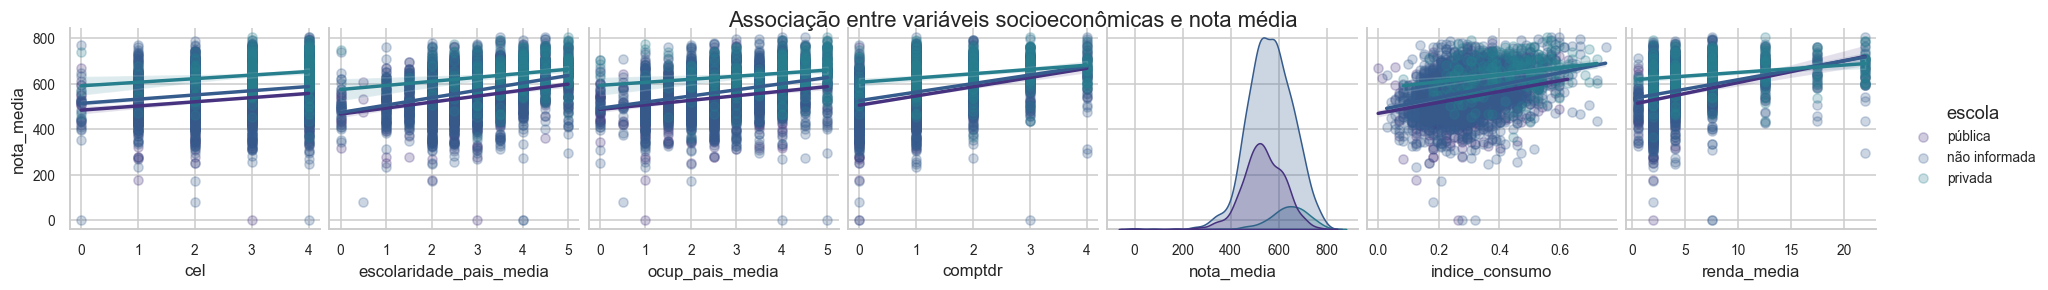

In [34]:
df_sample = df_corr.sample(5000, random_state=42)

g = sns.pairplot(
    df_sample,
    x_vars=colunas_pairplot,
    y_vars=["nota_media"],
    kind="reg",
    diag_kind="kde",
    hue="escola",
    plot_kws={
        "scatter_kws": {"alpha": 0.25}
    }
)

g.fig.suptitle(
    "Associação entre variáveis socioeconômicas e nota média",
    y=1.02
)

plt.show()

## 15) Conclusão - Análise Exploratória (EDA)

A análise exploratória revelou alguns padrões consistentes nos microdados do ENEM em Minas Gerais:

* candidatos provenientes de famílias com maior escolaridade e ocupação dos pais mais qualificadas tendem a apresentar maior desempenho médio;
* há associação positiva entre renda familiar e nota média;
* candidatos de escolas privadas apresentam desempenho médio superior ao observado em escolas públicas;
* diferenças regionais também estão presentes, refletindo desigualdades socioeconômicas dentro do estado.

Esses padrões reforçam a importância de considerar variáveis socioeconômicas familiares na modelagem do desempenho educacional.

A etapa seguinte do projeto utiliza essas variáveis para construir um modelo explicativo-estrutural do desempenho médio no ENEM.
